In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn as sk
from patsy import dmatrices
import statsmodels.api as sm

In [2]:
df=pd.read_csv("NY-House-Dataset.csv")

In [ ]:
df

In [20]:
np.max(dfs.PRICE)

np.int64(65000000)

In [69]:
dfs = df.drop(["BROKERTITLE", "ADDRESS", "STATE", "MAIN_ADDRESS", "ADMINISTRATIVE_AREA_LEVEL_2", "LONG_NAME"], axis=1)
dfs = dfs[dfs["PRICE"] <= 3*np.std(dfs["PRICE"])]

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in m

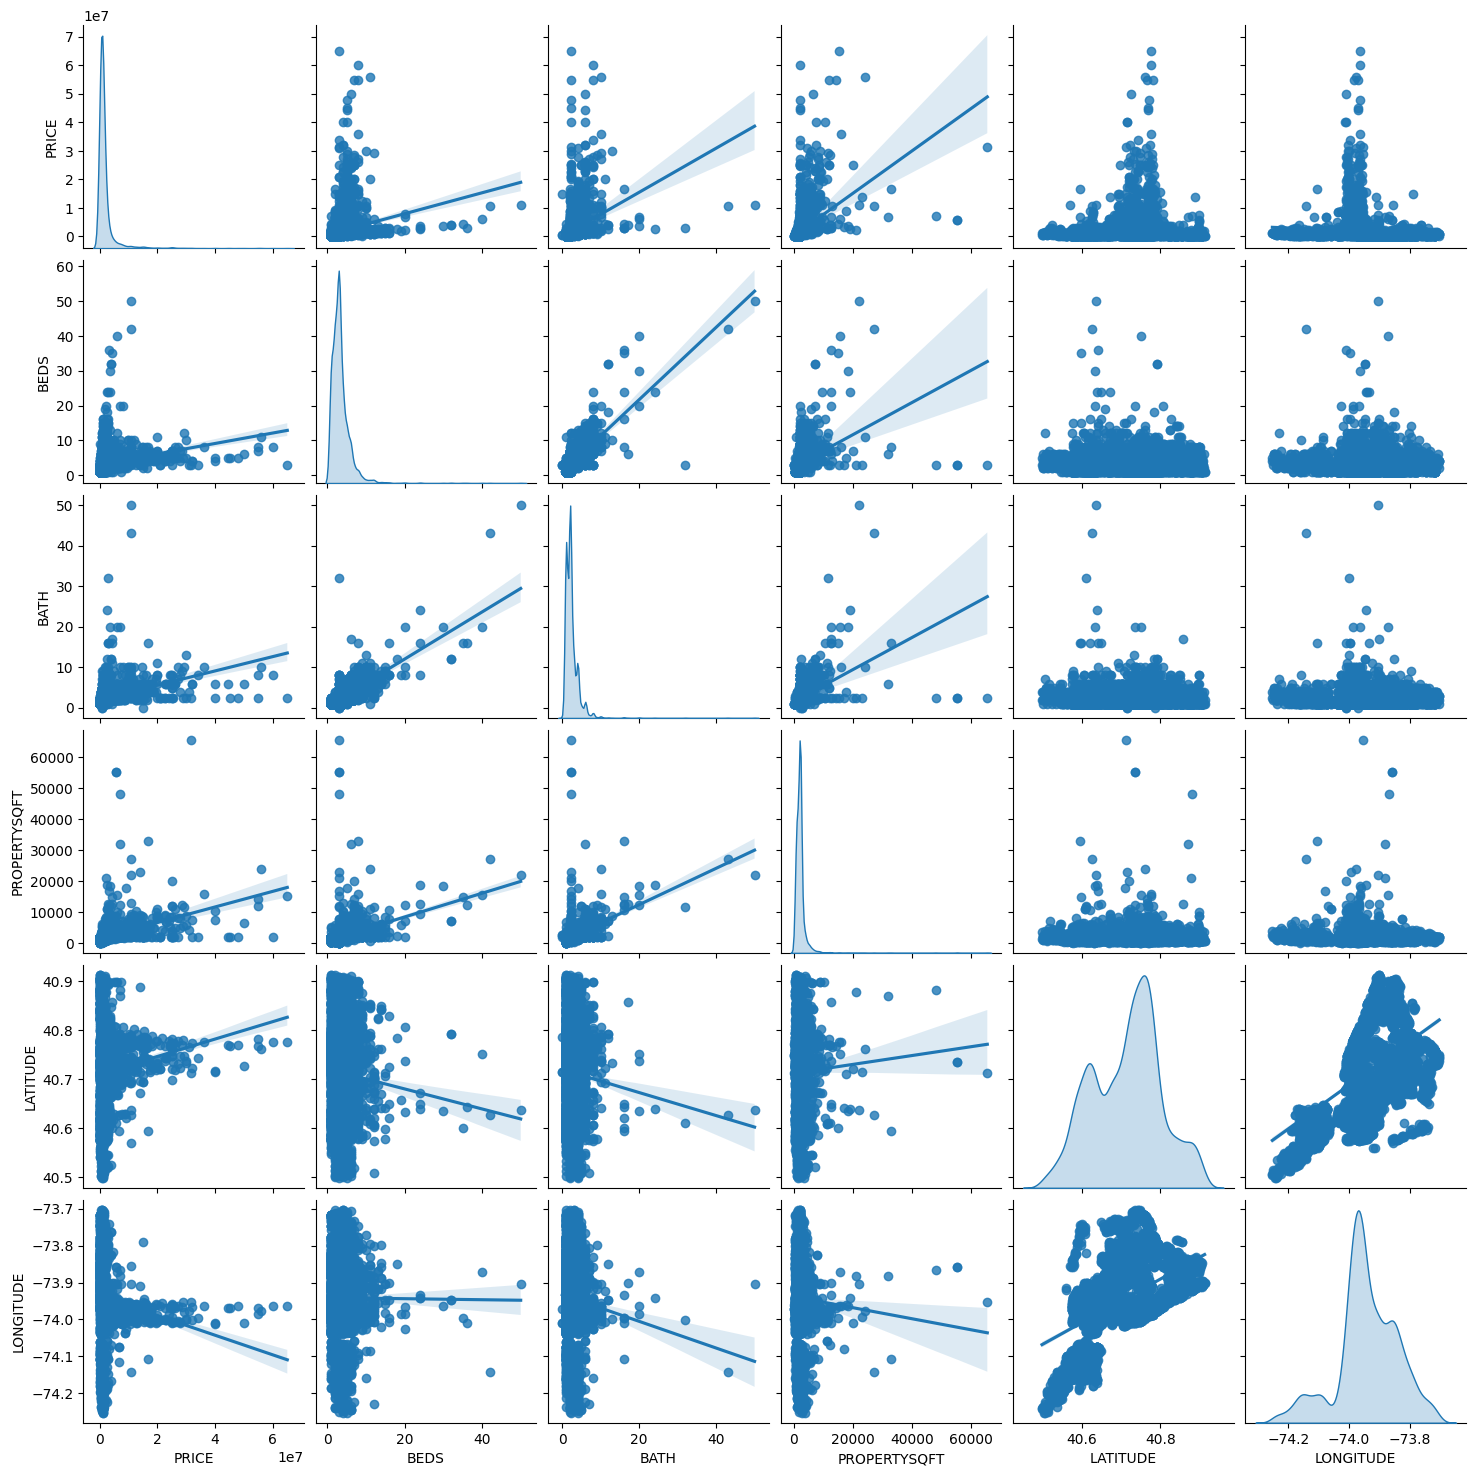

In [21]:
sns.pairplot(dfs, diag_kind="kde", kind="reg")

In [23]:
numerical_columns = dfs.select_dtypes("number").columns.to_list()
categorical_columns = dfs.select_dtypes(exclude="number").columns.to_list()

<Axes: >

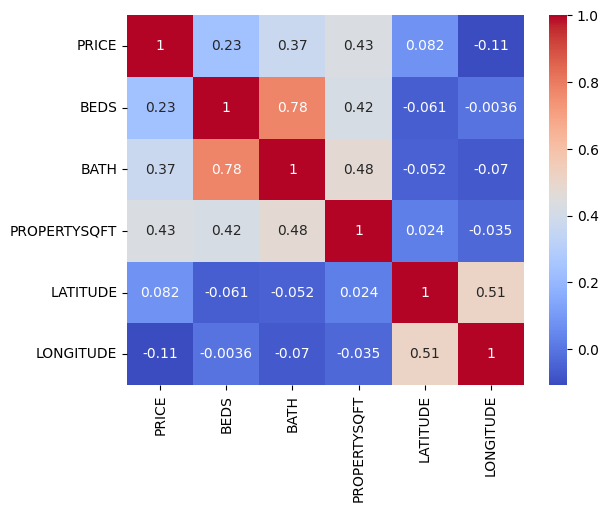

In [27]:
sns.heatmap(dfs[numerical_columns].corr(), cmap="coolwarm", annot=True)

In [58]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

dfs_c = add_constant(dfs)

vif = pd.DataFrame()
vif["feature"] = dfs_c[numerical_columns].columns
vif["VIF"] = [variance_inflation_factor(dfs_c[numerical_columns], i) for i in range(dfs_c[numerical_columns].shape[1])]

vif

,feature,VIF
0,PRICE,1.579394
1,BEDS,6.861193
2,BATH,7.168701
3,PROPERTYSQFT,2.706537
4,LATITUDE,105771.027651
5,LONGITUDE,105813.097338


/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


<Axes: xlabel='PROPERTYSQFT', ylabel='LOGPRICE'>

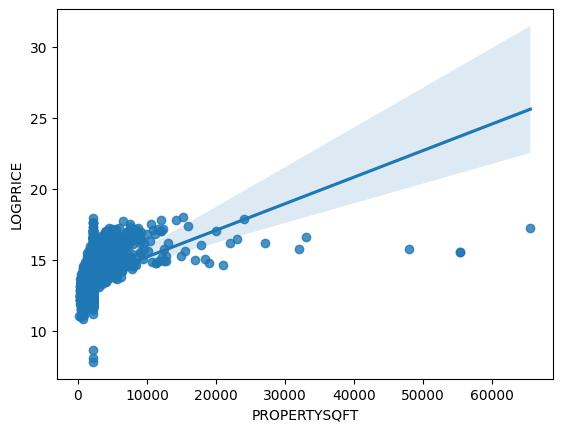

In [101]:
from statistics import kde

dfs['LOGPRICE'] = np.log(dfs['PRICE'])

sns.regplot(data=dfs, y="LOGPRICE", x="PROPERTYSQFT")

In [102]:
y, X = dmatrices("LOGPRICE ~ BEDS + BATH + PROPERTYSQFT + C(LOCALITY)", data=dfs)

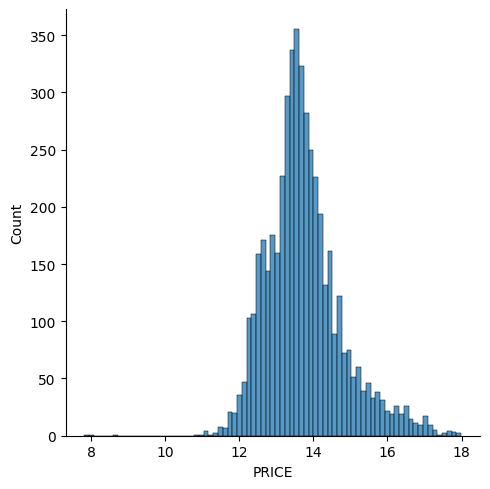

In [112]:
sns.displot(np.log(dfs['PRICE']))

<Axes: xlabel='PROPERTYSQFT', ylabel='LOGPRICE'>

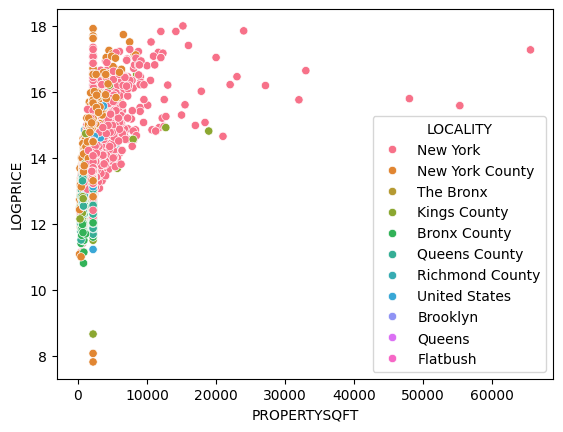

In [104]:
sns.scatterplot(dfs, x="PROPERTYSQFT", y="LOGPRICE", hue="LOCALITY")

In [113]:
glm_gamma = sm.GLM(y, X, family=sm.families.Gamma(link=sm.families.links.Log()))

model_gamma = glm_gamma.fit()
model_gamma.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:               LOGPRICE   No. Observations:                 4799
Model:                            GLM   Df Residuals:                     4785
Model Family:                   Gamma   Df Model:                           13
Link Function:                    Log   Scale:                       0.0028339
Method:                          IRLS   Log-Likelihood:                -5341.8
Date:                Thu, 03 Jul 2025   Deviance:                       13.851
Time:                        19:18:36   Pearson chi2:                     13.6
No. Iterations:                    16   Pseudo R-squ. (CS):             0.5864
Covariance Type:            nonrobust                                         
==================================================================================================
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                          2.4997      0.004    624.553      0.000       2.492       2.508
C(LOCALITY)[T.Brooklyn]            0.0788      0.022      3.566      0.000       0.035       0.122
C(LOCALITY)[T.Flatbush]            0.0769      0.053      1.441      0.150      -0.028       0.182
C(LOCALITY)[T.Kings County]        0.0560      0.005     12.034      0.000       0.047       0.065
C(LOCALITY)[T.New York]            0.0801      0.004     19.167      0.000       0.072       0.088
C(LOCALITY)[T.New York County]     0.1049      0.004     24.363      0.000       0.096       0.113
C(LOCALITY)[T.Queens]              0.0386      0.022      1.746      0.081      -0.005       0.082
C(LOCALITY)[T.Queens County]       0.0250      0.005      5.498      0.000       0.016       0.034
C(LOCALITY)[T.Richmond County]     0.0235      0.008      2.940      0.003       0.008       0.039
C(LOCALITY)[T.The Bronx]           0.0111      0.024      0.461      0.645      -0.036       0.058
C(LOCALITY)[T.United States]       0.0672      0.010      6.987      0.000       0.048       0.086
BEDS                              -0.0020      0.000     -4.136      0.000      -0.003      -0.001
BATH                               0.0166      0.001     25.386      0.000       0.015       0.018
PROPERTYSQFT                    6.646e-06   3.73e-07     17.812      0.000    5.91e-06    7.38e-06
==================================================================================================
"""

In [117]:
glm_gauss = sm.GLM(y, X, family=sm.families.Gaussian(link=sm.families.links.Identity()))
model_gauss = glm_gauss.fit()
model_gauss.summary()
y_pred_gauus = model_gauss.predict(X)
y_pred_gamma = model_gamma.predict(X)

In [125]:
ols = sm.OLS(y, X)
model_ols = ols.fit()
model_ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               LOGPRICE   R-squared:                       0.453
Model:                            OLS   Adj. R-squared:                  0.451
Method:                 Least Squares   F-statistic:                     304.7
Date:                Thu, 03 Jul 2025   Prob (F-statistic):               0.00
Time:                        19:22:31   Log-Likelihood:                -5461.3
No. Observations:                4799   AIC:                         1.095e+04
Df Residuals:                    4785   BIC:                         1.104e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
==================================================================================================
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                         12.1573      0.057    213.836      0.000      12.046      12.269
C(LOCALITY)[T.Brooklyn]            1.0392      0.314      3.312      0.001       0.424       1.654
C(LOCALITY)[T.Flatbush]            0.9962      0.758      1.314      0.189      -0.490       2.483
C(LOCALITY)[T.Kings County]        0.7218      0.066     10.912      0.000       0.592       0.852
C(LOCALITY)[T.New York]            1.0623      0.059     17.904      0.000       0.946       1.179
C(LOCALITY)[T.New York County]     1.4004      0.061     22.896      0.000       1.280       1.520
C(LOCALITY)[T.Queens]              0.4886      0.314      1.557      0.120      -0.127       1.104
C(LOCALITY)[T.Queens County]       0.3112      0.065      4.817      0.000       0.185       0.438
C(LOCALITY)[T.Richmond County]     0.2977      0.113      2.628      0.009       0.076       0.520
C(LOCALITY)[T.The Bronx]           0.1349      0.343      0.394      0.694      -0.537       0.807
C(LOCALITY)[T.United States]       0.8783      0.137      6.427      0.000       0.610       1.146
BEDS                              -0.0285      0.007     -4.100      0.000      -0.042      -0.015
BATH                               0.2173      0.009     23.401      0.000       0.199       0.235
PROPERTYSQFT                    9.492e-05    5.3e-06     17.909      0.000    8.45e-05       0.000
==============================================================================
Omnibus:                      939.826   Durbin-Watson:                   1.971
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            20784.499
Skew:                          -0.337   Prob(JB):                         0.00
Kurtosis:                      13.173   Cond. No.                     2.23e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.23e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

AttributeError: 'DesignMatrix' object has no attribute 'corr'

In [ ]:

y_pred_ols = model_ols.predict(X)

In [120]:
from sklearn.metrics import mean_absolute_error, mean_squared_error


print(mean_absolute_error(y, y_pred_gauus), mean_absolute_error(y, y_pred_gamma))
print(mean_squared_error(y, y_pred_gauus), mean_squared_error(y, y_pred_gamma))

0.5341788598481714 0.5356917946947393
0.5701419408894385 0.649947489219965


<Axes: >

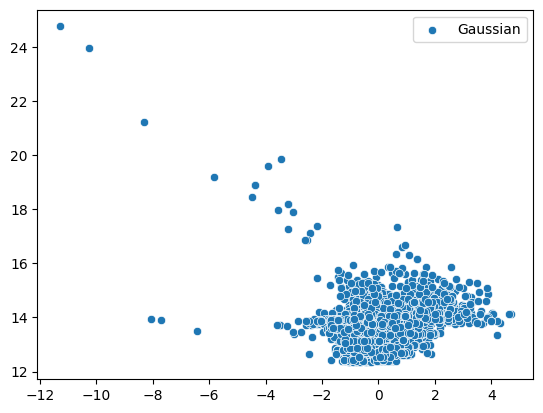

In [123]:
sns.scatterplot(x=model_gauss.resid_anscombe, y=y_pred_gauus, label="Gaussian")

In [ ]:
np.exp(0.325)


np.float64(1.3840306459807514)

In [ ]:
y_pred = model.predict(X)

In [110]:
# Y_pred and y side-by-side
pred_df = pd.DataFrame({"y_pred": y_pred, "y": pd.DataFrame(y).values.flatten()})
pred_df.head()

,y_pred,y
0,13.711127,12.660328
1,13.711578,12.468437
2,13.373040,11.141862
3,14.867473,17.822844
4,13.865892,13.444447


<Axes: xlabel='PROPERTYSQFT', ylabel='PRICE'>

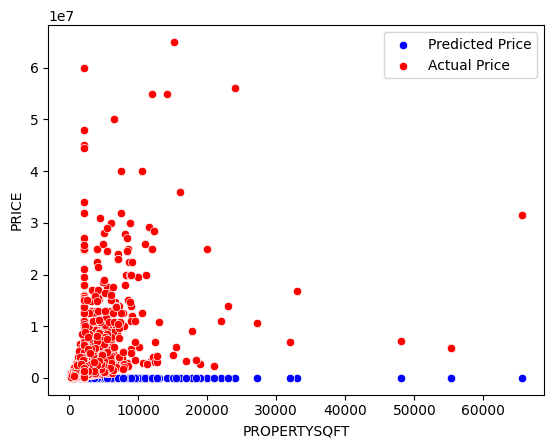

In [107]:
# Plot predicted values and actual price against PROPERTYSQFT
import seaborn as sns

# Define mask
mask = y_pred < 4_000_000

# Filter and plot
sns.scatterplot(x=dfs["PROPERTYSQFT"][mask], y=y_pred[mask], label="Predicted Price", color="blue")

# Plot the actual price as second colour
sns.scatterplot(x=dfs["PROPERTYSQFT"][mask], y=dfs["PRICE"][mask], label="Actual Price", color="red")

<Axes: xlabel='PROPERTYSQFT', ylabel='PRICE'>

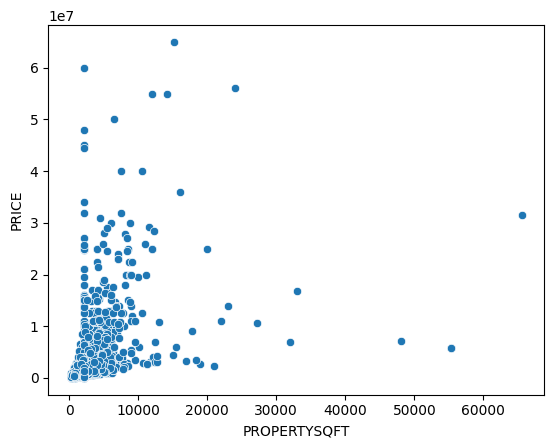

In [52]:
sns.scatterplot(data = dfs, x="PROPERTYSQFT", y="PRICE")

In [132]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mean_absolute_error(y, y_pred)
np.median(y)

array(13.62313867)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
scaler = StandardScaler()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Fit the scaler on the training data
scaler.fit(X_train)
# Transform the training data
X_train_scaled = scaler.transform(X_train)
# Transform the test data
X_test_scaled = scaler.transform(X_test)

In [141]:
from xgboost import XGBRegressor
xgb_model = XGBRegressor(objective='reg:squarederror', n_estimators=1000, random_state=42)
xgb_model.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_model.predict(X_test_scaled)
from sklearn.metrics import mean_absolute_error, mean_squared_error
print("XGBoost MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("XGBoost MSE:", mean_squared_error(y_test, y_pred_xgb))

# Plot predicted values and actual price against PROPERTYSQFT
sns.scatterplot(x=dfs["PROPERTYSQFT"][mask], y=y_pred_xgb[mask], label="Predicted Price (XGBoost)", color="green")

XGBoost MAE: 0.4602184983857694
XGBoost MSE: 0.4607523288192148


IndexError: boolean index did not match indexed array along axis 0; size of axis is 960 but size of corresponding boolean axis is 4799